In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
main_path = "/content/drive/MyDrive/AI Models/Skills Extraction Model"

In [3]:
# Install safetensors if not already installed
!pip install safetensors

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib as mt
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import MultiLabelBinarizer
from transformers import AutoTokenizer
from datasets import load_dataset
import pickle as pk
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import safetensors.torch

## Dataset

In [5]:
hf_dataset = load_dataset("includecctype/skills_extraction_from_sentence", split="train")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/109 [00:00<?, ?B/s]

dataset.json:   0%|          | 0.00/52.0k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [6]:
features = [item['sentence'] for item in hf_dataset]

In [7]:
labels = [item['skills'] for item in hf_dataset]

In [8]:
mlb = MultiLabelBinarizer()

In [9]:
binary_labels = mlb.fit_transform(labels)

In [10]:
with open(f'{main_path}/skill_encoder.pkl', 'wb') as file:
    pk.dump(mlb, file)

## Transformer

In [11]:
tokeniser = AutoTokenizer.from_pretrained('google-bert/bert-base-cased')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

## Dataset Class

In [12]:
class SkillExtractionDataset(Dataset):
    def __init__(self, feature, label, tokeniser):
        self.feature = feature
        self.label = label
        self.tokeniser = tokeniser

    def __len__(self):
        return len(self.label)

    def __getitem__(self, idx):
        current_feature = self.feature[idx]
        current_label = self.label[idx]

        tokenised_feature = self.tokeniser(
            text=current_feature,
            padding="max_length",
            truncation=True,
            max_length=100,
            return_tensors="pt",
        )

        input_ids = tokenised_feature["input_ids"].squeeze(0)
        label_tensor = torch.tensor(current_label, dtype=torch.float32)

        return input_ids, label_tensor

In [13]:
pt_dataset = SkillExtractionDataset(feature=features, label=binary_labels, tokeniser=tokeniser)

In [14]:
dataloader = DataLoader(pt_dataset, batch_size=60, shuffle=True)

## Model

In [15]:
class SkillExtractionModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.embedding = nn.Embedding(35000, 20)
        self.conv1 = nn.Conv1d(100, 300, 3)
        self.conv2 = nn.Conv1d(300, 100, 3)
        self.linear1 = nn.Linear(16, 1)
        self.linear2 = nn.Linear(100, num_classes)

    def forward(self, feature):
        x = self.embedding(feature)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.linear1(x)
        x = x.squeeze(-1)
        x = self.linear2(x)

        return x

In [16]:
model = SkillExtractionModel(num_classes=len(mlb.classes_))

## Training

In [17]:
optimiser = optim.AdamW(model.parameters(), lr=0.001)

In [18]:
criterion = nn.BCEWithLogitsLoss()

In [19]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimiser, factor=0.8)

In [20]:
for i in range(1000):
    for batch in dataloader:
        feature, label = batch

        prediction = model(feature)

        loss = criterion(prediction, label)

        print(loss)

        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

    scheduler.step(loss)

Streaming output truncated to the last 5000 lines.
tensor(1.2557e-05, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(1.1928e-05, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(1.3792e-05, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(1.1376e-05, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(1.3675e-05, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(1.1371e-05, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(1.1738e-05, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(1.2094e-05, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(1.1911e-05, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(1.2139e-05, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(1.2683e-05, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(1.2885e-05, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(1.1377e-05, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(1.2991e-05, grad_fn=<BinaryCrossEntropyWithLogitsBackward0

In [21]:
safetensors.torch.save_model(model, f'{main_path}/model.safetensors')

## Evaluate

In [25]:
def evaluate_model(model, dataloader, mlb):
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for feature, label in dataloader:
            # Ensure feature is on the correct device if model expects it
            feature = feature #.to(device) # Uncomment if using a specific device like 'cuda'
            prediction = model(feature)
            # Apply sigmoid to get probabilities for multi-label classification
            probabilities = torch.sigmoid(prediction)
            # Convert probabilities to binary predictions based on a threshold (e.g., 0.5)
            predicted_labels = (probabilities > 0.5).float()

            all_predictions.extend(predicted_labels.cpu().numpy())
            all_labels.extend(label.cpu().numpy())

    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)

    # Calculate overall accuracy
    accuracy = accuracy_score(all_labels, all_predictions)

    # Calculate precision, recall, f1-score for each label and overall
    precision, recall, f1_score, _ = precision_recall_fscore_support(
        all_labels, all_predictions, average=None, zero_division=0
    )

    # Macro average for overall precision, recall, f1-score
    macro_precision, macro_recall, macro_f1_score, _ = precision_recall_fscore_support(
        all_labels, all_predictions, average='macro', zero_division=0
    )

    metrics = {
        'accuracy': accuracy,
        'macro_precision': macro_precision,
        'macro_recall': macro_recall,
        'macro_f1_score': macro_f1_score,
        'per_label_precision': precision,
        'per_label_recall': recall,
        'per_label_f1_score': f1_score,
        'labels': mlb.classes_.tolist()
    }
    return metrics

In [26]:
# Assuming 'model', 'dataloader', and 'mlb' are already defined from previous steps
# If you have a separate test or validation dataloader, use that instead.
evaluation_metrics = evaluate_model(model, dataloader, mlb)

print(f"Overall Accuracy: {evaluation_metrics['accuracy']:.4f}")
print(f"Macro Precision: {evaluation_metrics['macro_precision']:.4f}")
print(f"Macro Recall: {evaluation_metrics['macro_recall']:.4f}")
print(f"Macro F1-Score: {evaluation_metrics['macro_f1_score']:.4f}")

Overall Accuracy: 1.0000
Macro Precision: 1.0000
Macro Recall: 1.0000
Macro F1-Score: 1.0000


### Per-Label Metrics Visualization

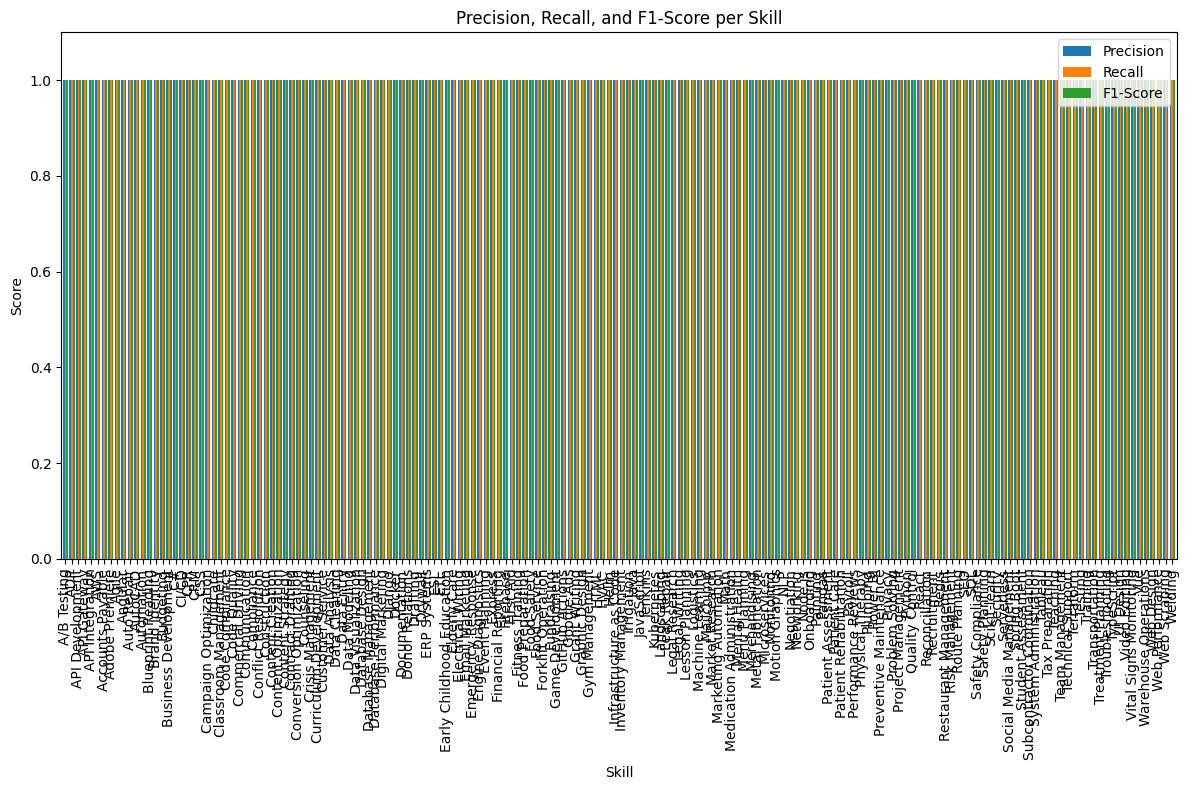

In [28]:
fig, ax = plt.subplots(figsize=(12, 8))

metrics_df = pd.DataFrame({
    'Skill': evaluation_metrics['labels'],
    'Precision': evaluation_metrics['per_label_precision'],
    'Recall': evaluation_metrics['per_label_recall'],
    'F1-Score': evaluation_metrics['per_label_f1_score']
})

metrics_df.set_index('Skill').plot(kind='bar', ax=ax, width=0.8)

ax.set_title('Precision, Recall, and F1-Score per Skill')
ax.set_ylabel('Score')
ax.set_xlabel('Skill')
ax.set_ylim(0, 1.1) # Set y-limit from 0 to 1 for metric scores
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()